A linear regression vs forest tree comparison for predicting price on an Airbnb dataset

In [ ]:
import pandas as pd
import numpy as np

# Drop unnecessary columns
listings = pd.read_csv('listings.csv')
listings = listings.drop(columns = ["host_id", "host_name", "last_review", "calculated_host_listings_count", "license", "name", "number_of_reviews", "number_of_reviews_ltm"])
# Drop null price rows
listings = listings.dropna(subset = ['price'])
# Combine hotel and shared rooms into one group
listings['room_type'] = listings['room_type'].replace({'Hotel room': "Other", 'Shared room': 'Other'})
listings.head(10)

,id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,reviews_per_month,availability_365
0,3176,Pankow,Prenzlauer Berg Südwest,52.53471,13.41810,Entire home/apt,105.0,63,0.76,140
1,9991,Pankow,Prenzlauer Berg Südwest,52.53269,13.41805,Entire home/apt,135.0,6,0.06,241
2,14325,Pankow,Prenzlauer Berg Nordwest,52.54813,13.40366,Entire home/apt,75.0,150,0.14,168
3,17904,Neukölln,Reuterstraße,52.49419,13.42166,Entire home/apt,32.0,93,1.57,72
4,20858,Pankow,Prenzlauer Berg Südwest,52.53711,13.40888,Entire home/apt,202.0,3,0.89,253
6,22677,Mitte,Brunnenstr. Süd,52.53355,13.40476,Entire home/apt,152.0,4,3.29,321
7,23834,Friedrichshain-Kreuzberg,Tempelhofer Vorstadt,52.49134,13.37975,Entire home/apt,65.0,185,0.53,0
8,26543,Pankow,Helmholtzplatz,52.54419,13.41956,Entire home/apt,260.0,180,1.09,365
9,28156,Pankow,Prenzlauer Berg Nordwest,52.54804,13.40349,Entire home/apt,70.0,150,0.19,166
10,30295,Pankow,Helmholtzplatz,52.54596,13.42291,Entire home/apt,172.0,4,2.75,277


/tmp/ipykernel_2318/2805403272.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  listings['log_price'] = np.log(listings['price'])


['latitude',
 'longitude',
 'minimum_nights',
 'reviews_per_month',
 'availability_365',
 'log_price',
 'room_type_Other',
 'room_type_Private room',
 'neighbourhood_group_Friedrichshain-Kreuzberg',
 'neighbourhood_group_Lichtenberg',
 'neighbourhood_group_Marzahn - Hellersdorf',
 'neighbourhood_group_Mitte',
 'neighbourhood_group_Neukölln',
 'neighbourhood_group_Pankow',
 'neighbourhood_group_Reinickendorf',
 'neighbourhood_group_Spandau',
 'neighbourhood_group_Steglitz - Zehlendorf',
 'neighbourhood_group_Tempelhof - Schöneberg',
 'neighbourhood_group_Treptow - Köpenick']

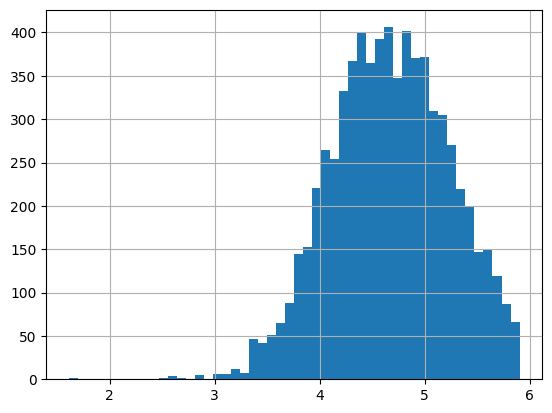

In [ ]:
# -------------------
# Viewing the data
# -------------------
# listings.isnull().sum()
# listings['room_type'].value_counts()
# listings.shape
# print(listings['price'].describe())
upper = listings['price'].quantile(0.99)
listings = listings[listings['price'] <= upper]
# -----------------------------------------------

listings['log_price'] = np.log(listings['price'])
listings['log_price'].hist(bins=50)

# ---------------------
# Feature Engineering
# ---------------------
# listings = pd.get_dummies(listings, columns=['room_type', 'neighbourhood_group'], drop_first=True)
listings = listings.drop(columns=['id','neighbourhood','price'])
listings = listings.dropna()
listings.columns.tolist()
# ----------------------

* After running the histogram on price vs counts, it was very skewed because of an expensive listing blocking out the rest of the data.
* I changed the prices column to only include the 99th percentiles of listings to see that the price distribution was skewed to the right.
* For this reason I applied a log transformation before modeling to improve linear regression performance.

**Testing/Training **

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# Split data
X = listings.drop(columns=['log_price'])
y = listings['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ------------------
# Linear Regression
# ------------------
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression RMSE {rmse_lr:.3f}")
print(f"Linear Regression R^2:{r2_lr:.3f}")

# -----------------
# Random Forest
# -----------------
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest RMSE {rmse_rf:.3f}")
print(f"Random Forest R^2:{r2_rf:.3f}")

Linear Regression RMSE 0.461
Linear Regression R^2:0.316
Random Forest RMSE 0.405
Random Forest R^2:0.472


**Feature Importance Plot**

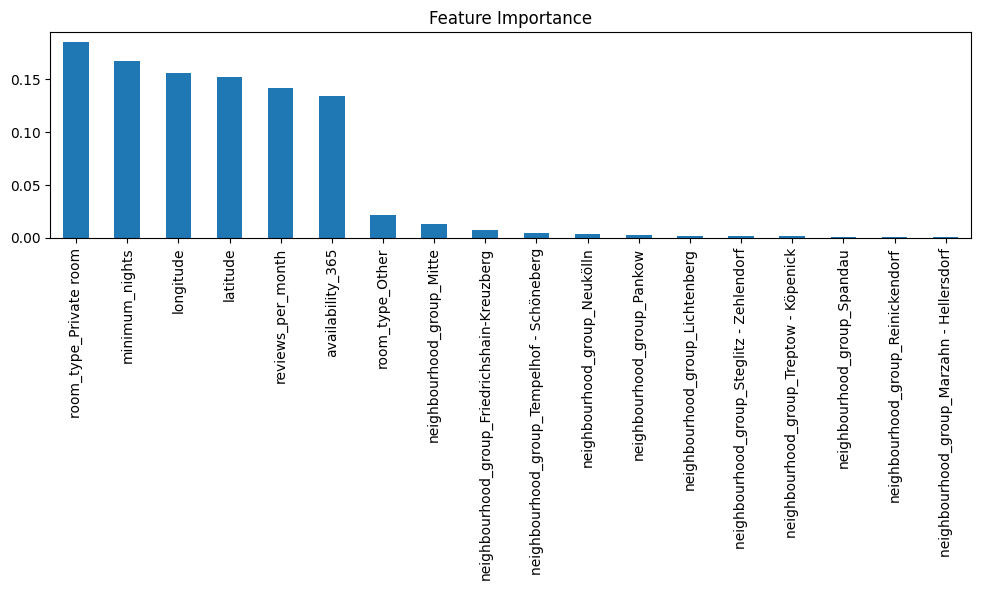

In [ ]:
import matplotlib.pyplot as plt

feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.plot(kind='bar')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

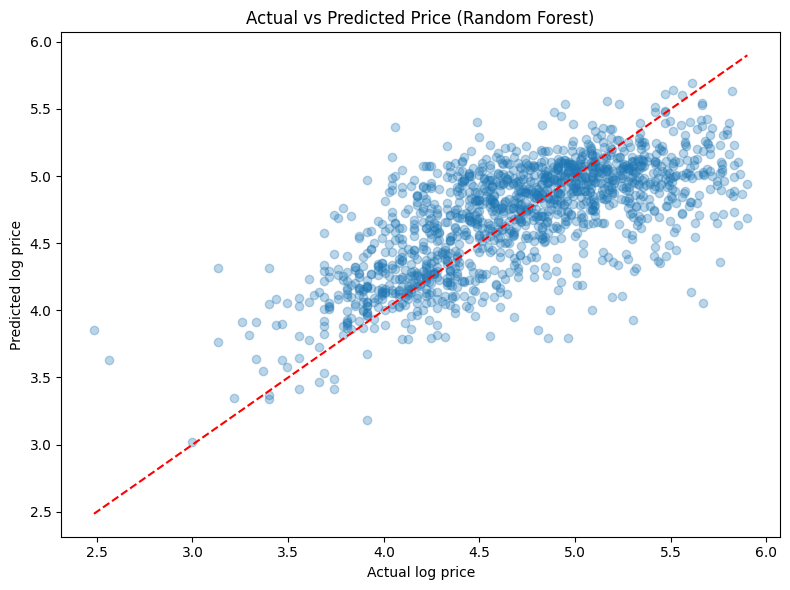

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual log price')
plt.ylabel('Predicted log price')
plt.title('Actual vs Predicted Price (Random Forest)')
plt.tight_layout()
plt.show()



* The points generally are clustered on the regression line showing the model is actually learning price patterns.
* Higher priced properties are harder to learn because of different amenities not in our database, that the model cannot take into account.
